# Data Profiling

The `us_employment` dataset contains monthly US employment data across various sectors. For this analysis, we will focus on the total "Total Nonfarm" employment.

In [1]:
# Install and load packages
install.packages(c("fpp3", "tidyverse", "scales"))

library(fpp3)
library(tidyverse)
library(scales)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching packages ──────────────────────────────────────────── fpp3 1.0.3 ──

✔ tibble      3.3.1     ✔ tsibble     1.2.0
✔ dplyr       1.2.0     ✔ tsibbledata 0.4.1
✔ tidyr       1.3.2     ✔ ggtime      0.2.0
✔ lubridate   1.9.5     ✔ feasts      0.5.0
✔ ggplot2     4.0.2     ✔ fable       0.5.0

── Conflicts ───────────────────────────────────────────────── fpp3_conflicts ──
✖ lubridate::date()    masks base::date()
✖ dplyr::filter()      masks stats::filter()
✖ tsibble::intersect() masks base::intersect()
✖ tsibble::interval()  masks lubridate::interval()
✖ dplyr::lag()         masks stats::lag()
✖ tsibble::setdiff()   masks base::setdiff()
✖ tsibble::union()     masks base::union()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ readr   2.2.0
✔ purrr   1.2.1     ✔ stringr 1.6.0
── Conflicts ────────────────────────────────────────── tidyver

In [2]:
# Filtering for Total Nonfarm employment
data <- us_employment %>%
  filter(Title == "All Employees, Total Nonfarm") %>%
  select(Month, Employed)

# Data Shape
print(paste("Number of observations:", nrow(data)))
print(paste("Time range:", min(data$Month), "to", max(data$Month)))

# Central Tendency and Dispersion
summary_stats <- data %>%
  as_tibble() %>%
  summarise(
    Mean = mean(Employed, na.rm = TRUE),
    Median = median(Employed, na.rm = TRUE),
    SD = sd(Employed, na.rm = TRUE),
    Min = min(Employed, na.rm = TRUE),
    Max = max(Employed, na.rm = TRUE)
  )

knitr::kable(summary_stats, caption = "Summary Statistics of US Employment (Total Nonfarm)")

[1] "Number of observations: 969"
[1] "Time range: 1939 Jan to 2019 Sep"




Table: Summary Statistics of US Employment (Total Nonfarm)

|    Mean| Median|       SD|   Min|    Max|
|-------:|------:|--------:|-----:|------:|
| 88857.4|  89099| 36344.67| 29296| 152243|

# Exploratory Data Analysis

## Time Series Visualization
We first plot the raw data to observe the overall trend.

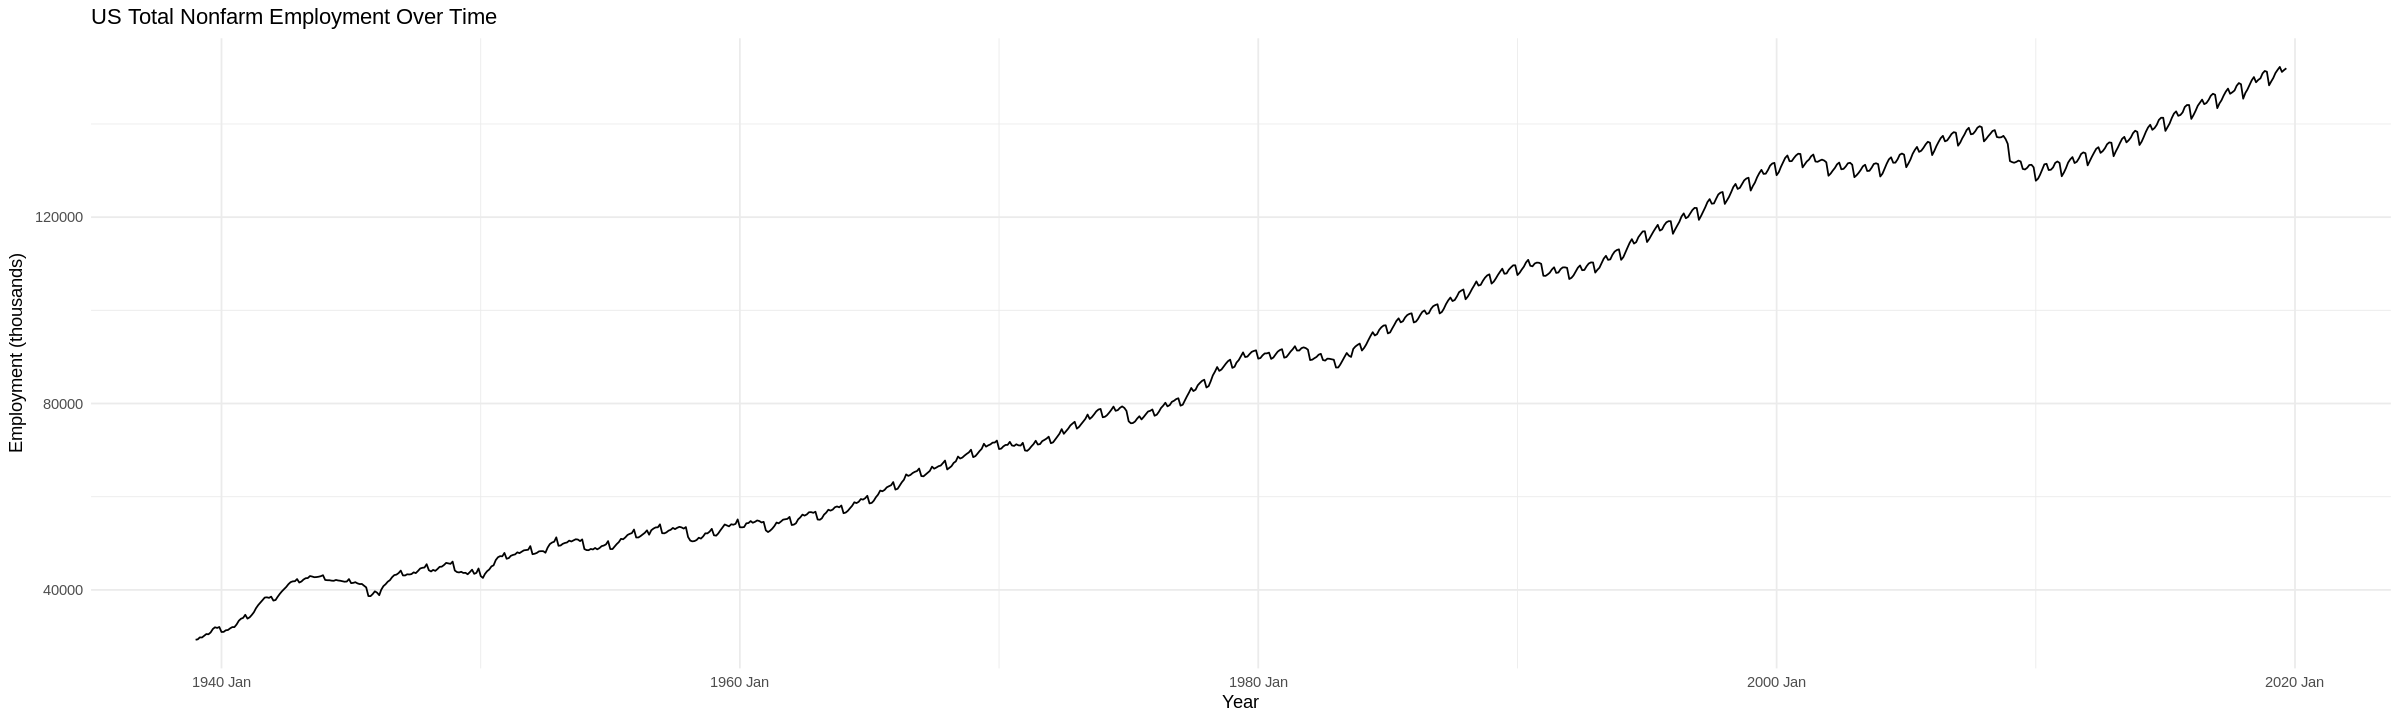

In [3]:
options(repr.plot.width = 20, repr.plot.height = 6)
data %>%
  autoplot(Employed) +
  labs(title = "US Total Nonfarm Employment Over Time",
       y = "Employment (thousands)",
       x = "Year") +
  theme_minimal()
options(repr.plot.width = 7, repr.plot.height = 5)

## Time-Series Decomposition
Decomposing the series into trend, seasonality, and remainders using STL.

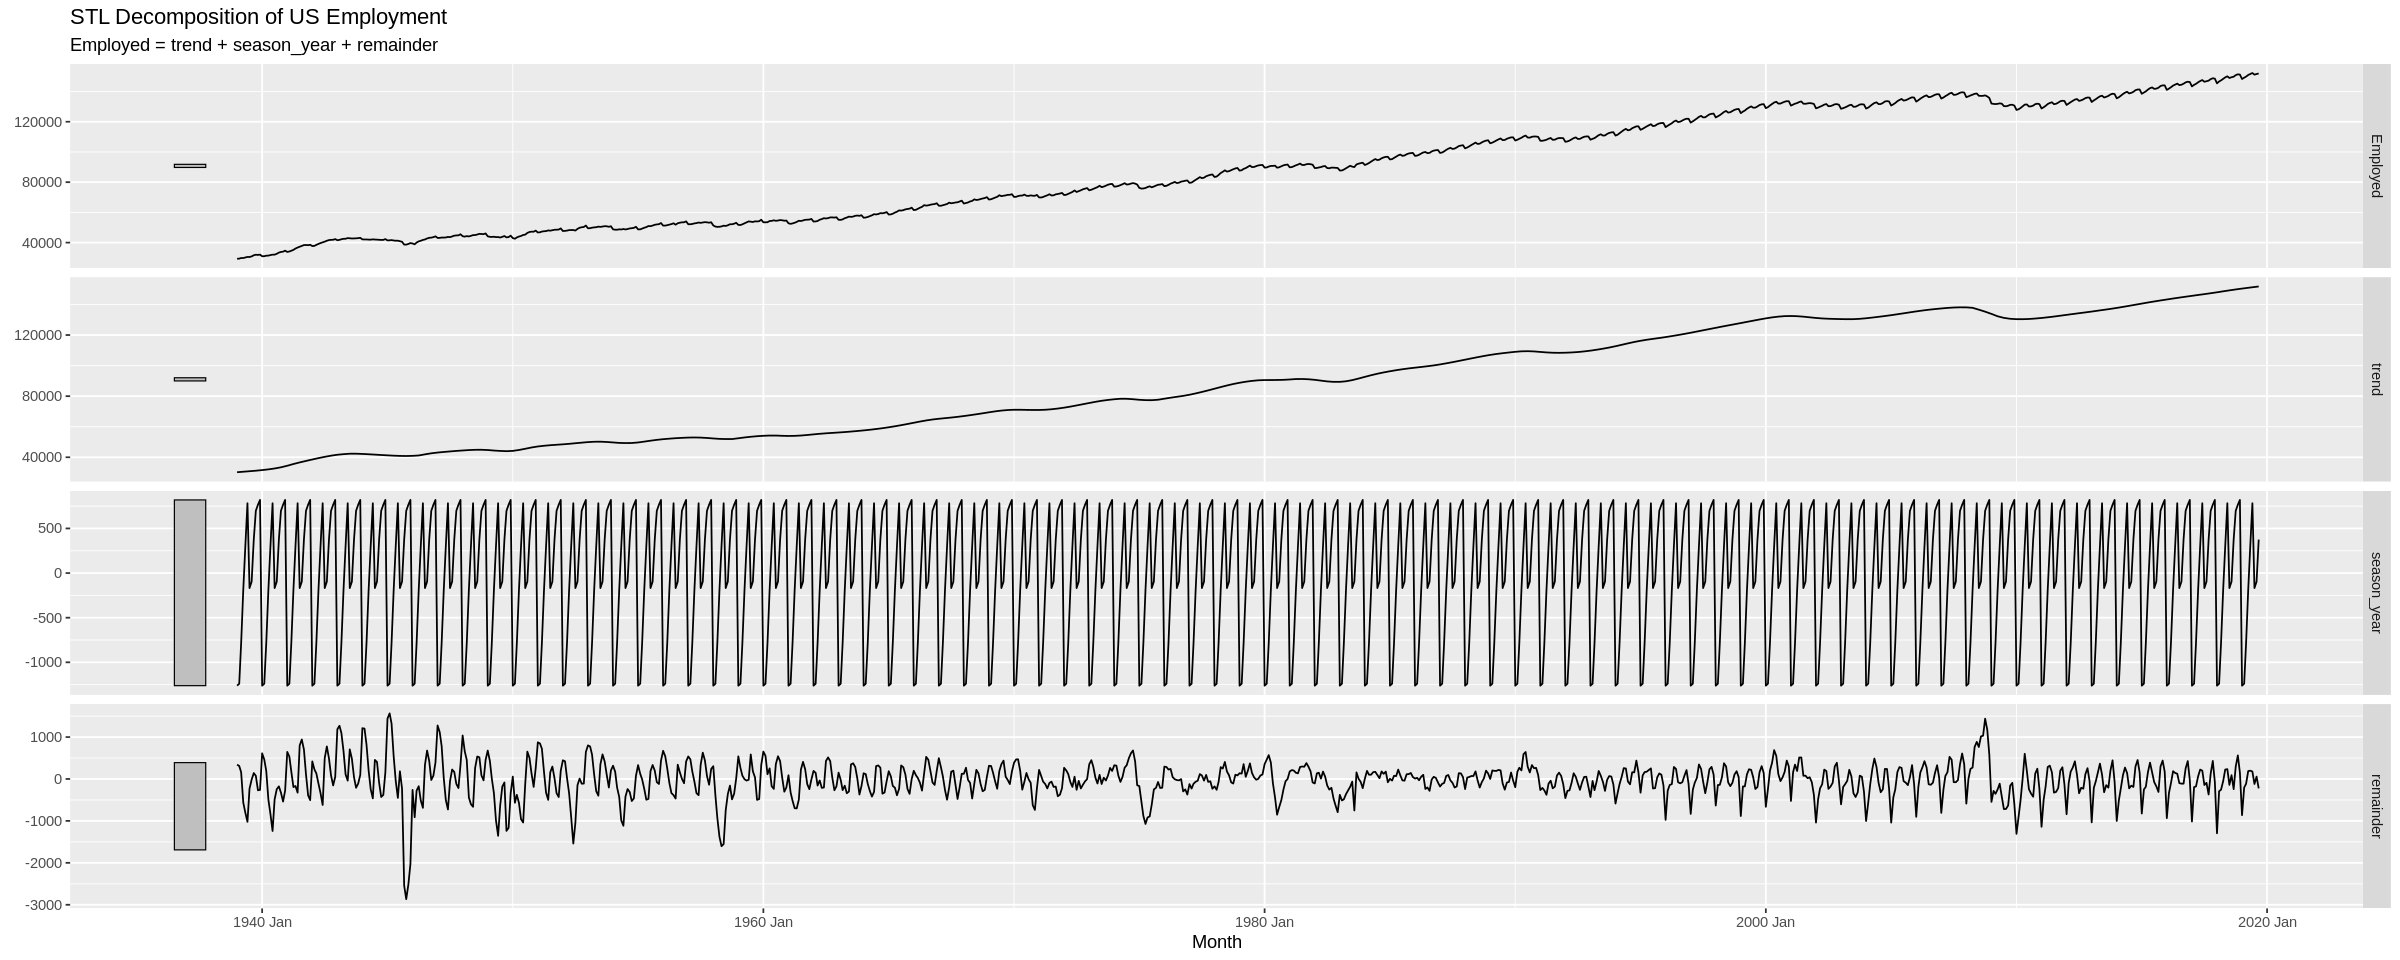

In [4]:
options(repr.plot.width = 20, repr.plot.height = 8)
data %>%
  model(STL(Employed ~ trend(window = 21) + season(window = "periodic"), robust = TRUE)) %>%
  components() %>%
  autoplot() +
  labs(title = "STL Decomposition of US Employment")

## ACF/PACF Analysis
Autocorrelation and Partial Autocorrelation functions help identify seasonality and potential AR/MA terms.

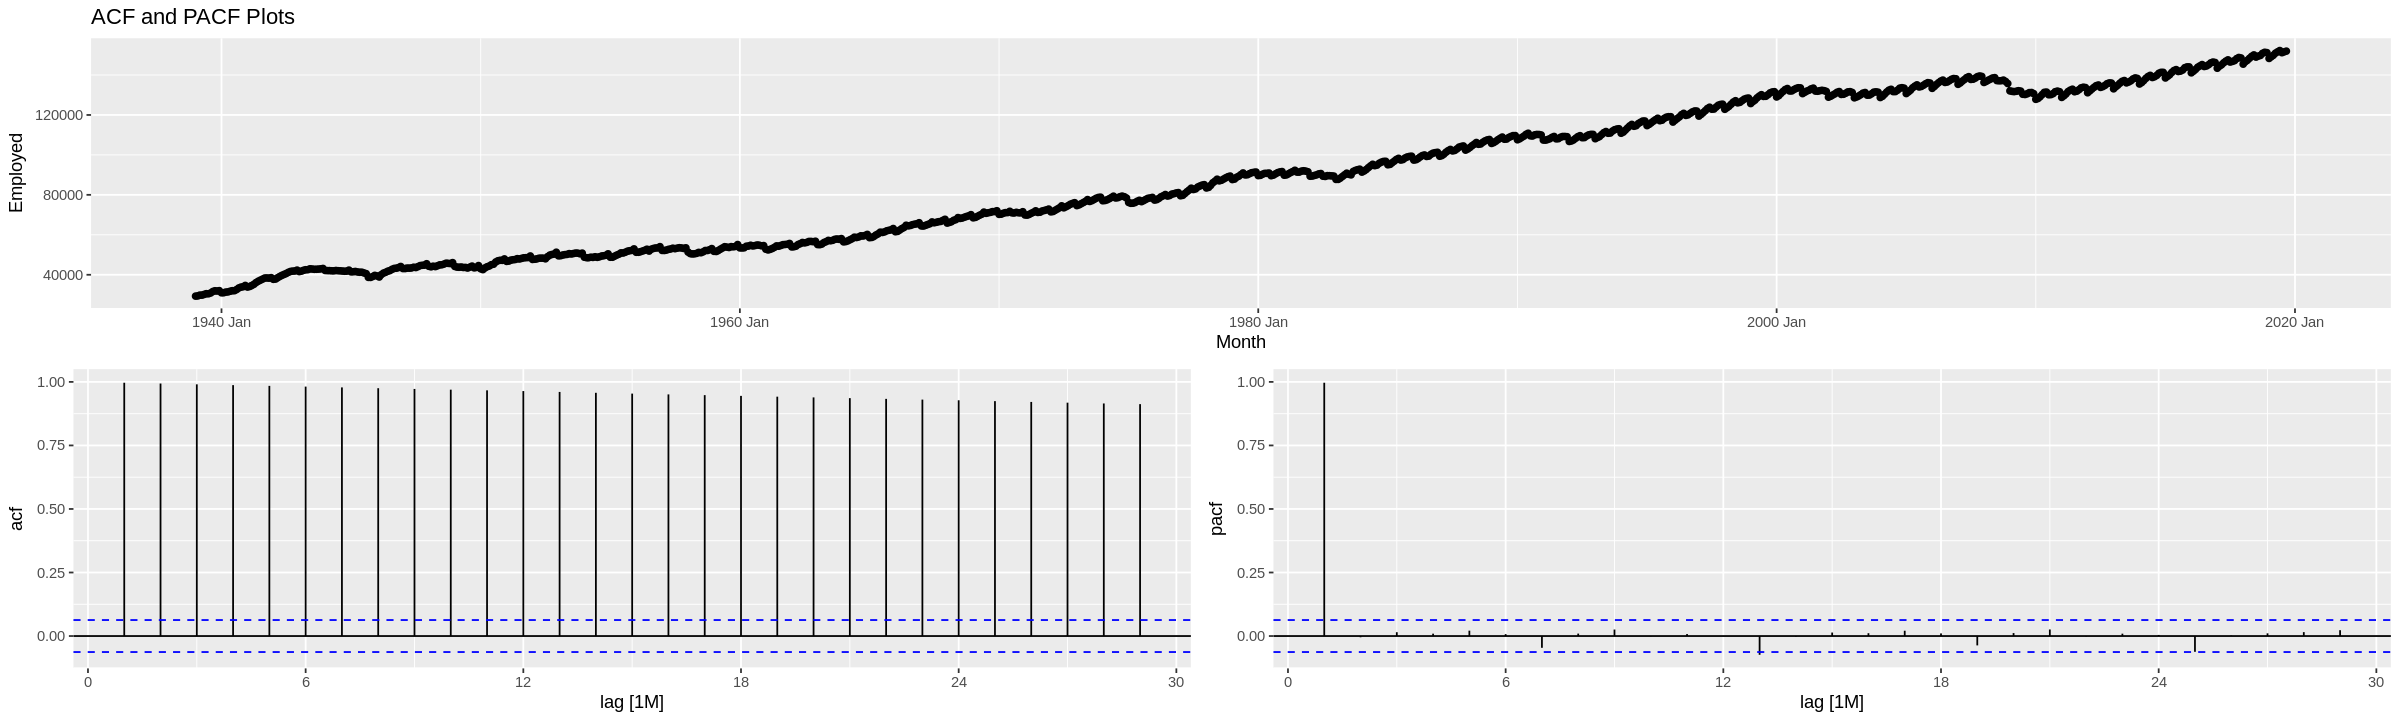

In [5]:
options(repr.plot.width = 20, repr.plot.height = 6)
data %>%
  gg_tsdisplay(Employed, plot_type = 'partial') +
  labs(title = "ACF and PACF Plots")

## Differencing
The data shows a clear non-stationary trend. We check the strength of seasonality and trend to determine if differencing is required.

Warning message:
“1 error encountered for feature 1
[1] 
”


<0 x 0 matrix>

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


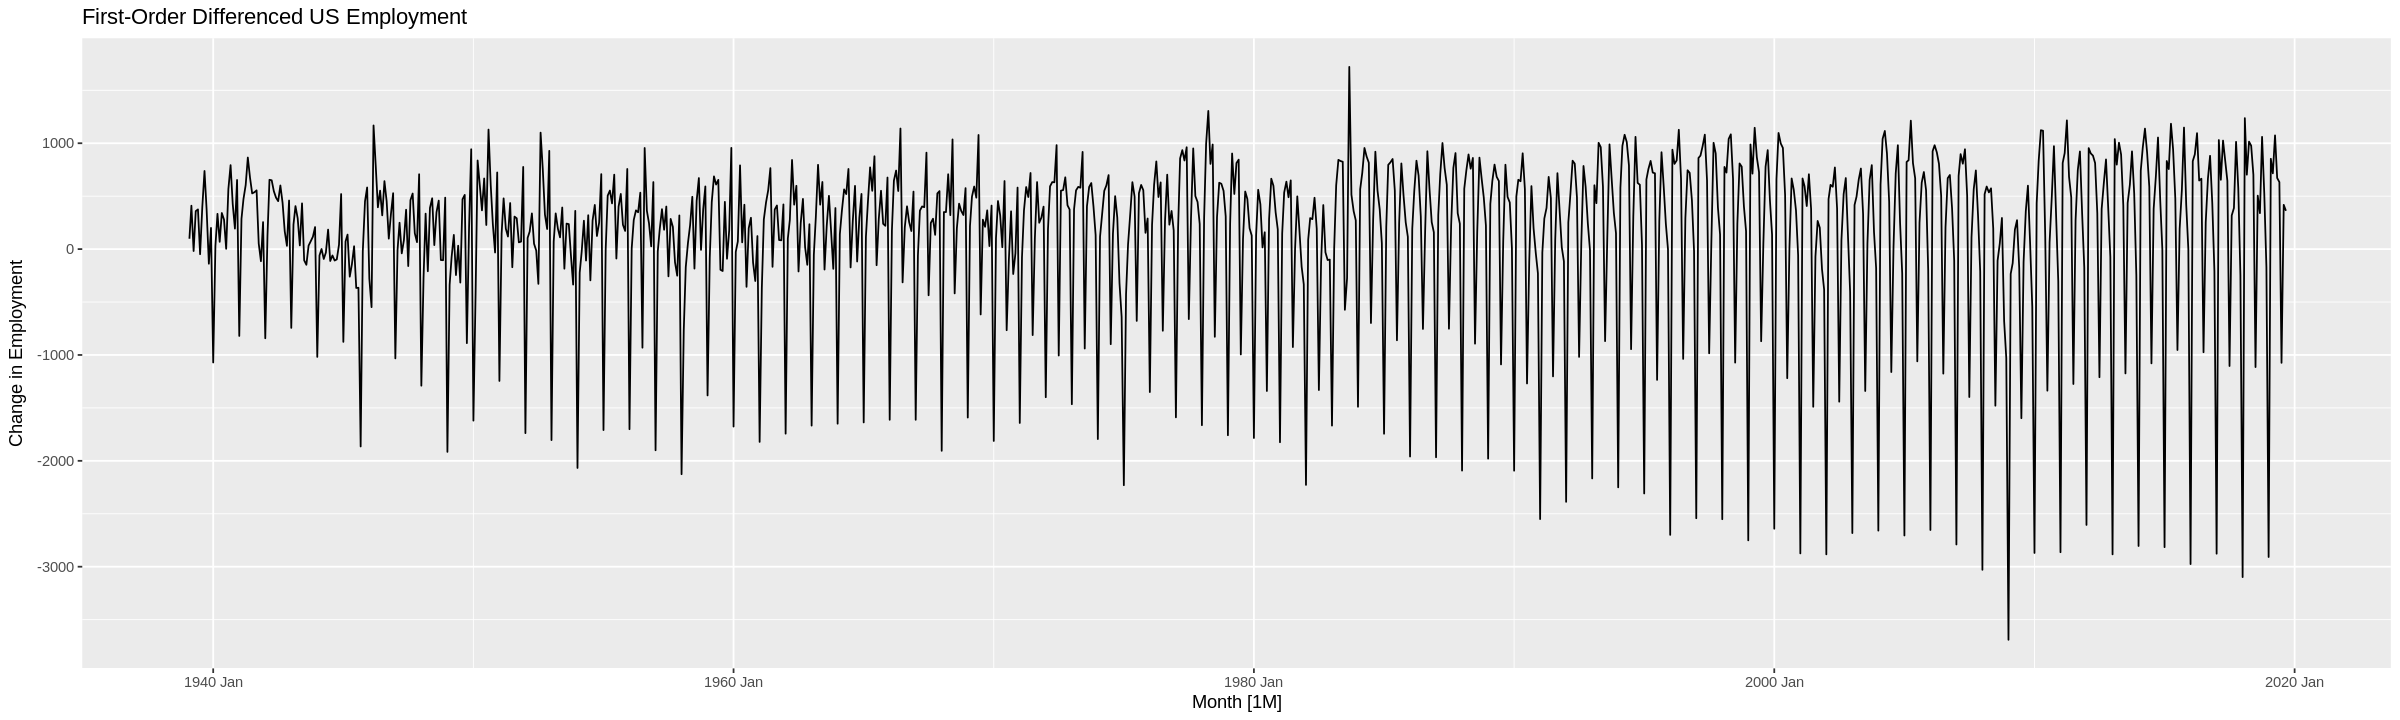

In [6]:
# Unit root tests for differencing
data %>%
  features(Employed, unitroot_ndiffs)

# Plotting differenced data to check for stationarity
data %>%
  autoplot(difference(Employed)) +
  labs(title = "First-Order Differenced US Employment",
       y = "Change in Employment")

# Model Training: Benchmarks
We split the data into training and testing sets (holding out the last 12 months).

In [7]:
train <- data %>% filter(Month < max(Month) - 11)
test <- data %>% filter(Month >= max(Month) - 11)

fit_benchmarks <- train %>%
  model(
    Mean = MEAN(Employed),
    Naive = NAIVE(Employed),
    SNaive = SNAIVE(Employed),
    Drift = RW(Employed ~ drift())
  )

## Model Training: Advanced Models
We include ETS, ARIMA, and TBATS/Dynamic Harmonic Regression.

In [8]:
# Removing ARIMA and DHR because they're both returning errors
fit_models <- train %>%
  model(
    ETS = ETS(Employed),
    # ARIMA = ARIMA(Employed ~ pdq(d = 1), stepwise = FALSE, approximation = FALSE),
    TBATS = decomposition_model(
      STL(Employed),
      ETS(season_adjust ~ season("N") + error("A") + trend("A"))
    ),
    # DHR = ARIMA(Employed ~ pdq(d = 1) + fourier(K = 2), stepwise = FALSE, approximation = FALSE)
  )

# Combine all models
all_models <- bind_cols(fit_benchmarks, fit_models)

## 5. Model Evaluation

### Metrics Comparison
We evaluate the performance using different evaluation metrics on the test set.

In [9]:
fc <- all_models %>%
  forecast(h = 12)

accuracy_metrics <- fc %>%
  accuracy(data) %>%
  arrange(RMSE)

knitr::kable(accuracy_metrics, caption = "Model Performance Comparison (Test Set)")



Table: Model Performance Comparison (Test Set)

|.model |.type |         ME|       RMSE|        MAE|        MPE|       MAPE|       MASE|      RMSSE|      ACF1|
|:------|:-----|----------:|----------:|----------:|----------:|----------:|----------:|----------:|---------:|
|TBATS  |Test  |   185.5931|   202.7250|   185.5931|  0.1232086|  0.1232086|  0.0897118|  0.0853443| 0.3697289|
|ETS    |Test  |   286.3498|   324.5614|   286.3498|  0.1898890|  0.1898890|  0.1384155|  0.1366357| 0.4617959|
|Drift  |Test  |   240.5546|  1035.1100|   900.9951|  0.1548412|  0.5985711|  0.4355221|  0.4357665| 0.4242630|
|Naive  |Test  |  1059.8333|  1545.2793|  1417.0000|  0.6969995|  0.9374337|  0.6849479|  0.6505404| 0.5168139|
|SNaive |Test  |  2439.5000|  2450.6352|  2439.5000|  1.6180228|  1.6180228|  1.1792029|  1.0316823| 0.6716709|
|Mean   |Test  | 62772.8020| 62782.8743| 62772.8020| 41.6086773| 41.6086773| 30.3430496| 26.4306896| 0.5168139|

### Best Model Forecast
Identifying the best model (lowest RMSE) and plotting its forecast against actual data.

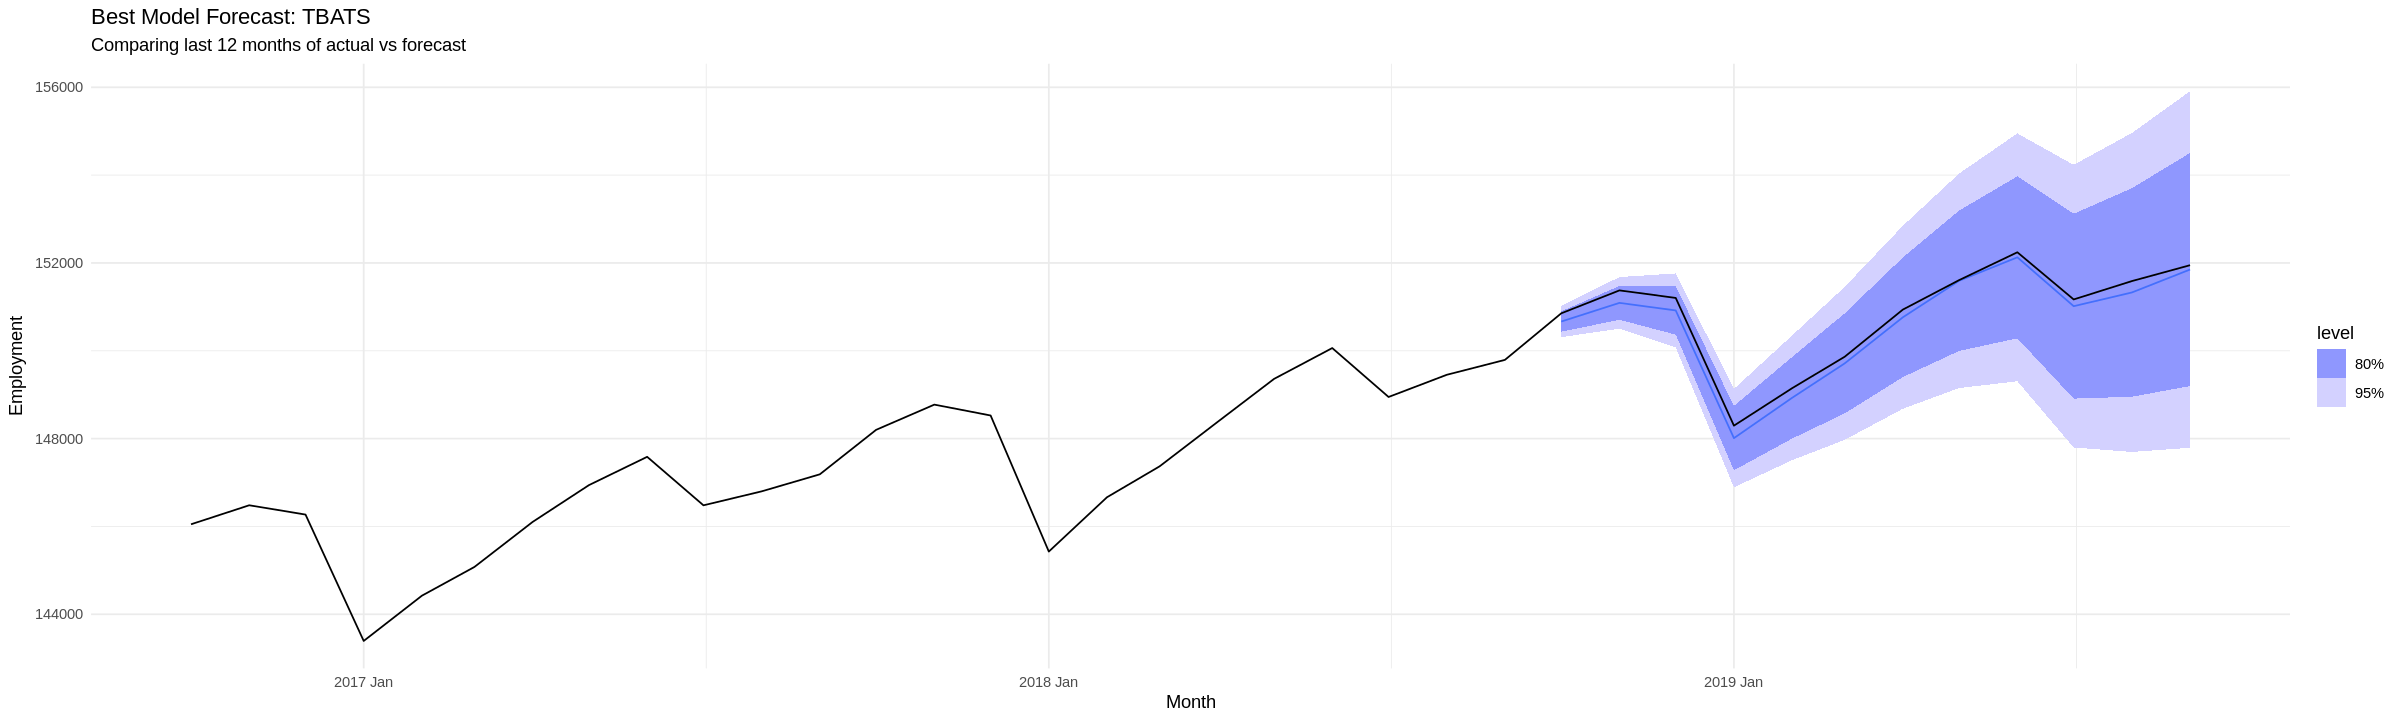

In [10]:
best_model_name <- accuracy_metrics$.model[1]

fc %>%
  filter(.model == best_model_name) %>%
  autoplot(data %>% filter(Month > max(Month) - 36)) +
  labs(title = paste("Best Model Forecast:", best_model_name),
       subtitle = "Comparing last 12 months of actual vs forecast",
       y = "Employment") +
  theme_minimal()

## 6. Summary and Recommendations

### Summary of Forecasts
Based on the **`r best_model_name`** model, US employment is projected to follow the current trend for the next 12 months. The model captures the underlying growth while accounting for historical volatility.

### Actionable Recommendations
1. **Capacity Planning**: Use the forecasted employment growth to adjust budget allocations for labor-dependent programs.
2. **Economic Monitoring**: The residual analysis from the TBATS/ETS models should be monitored; significant deviations from these forecasts might signal unexpected economic shifts.
3. **Model Refresh**: Given the sensitivity of employment data to policy changes, the model should be re-trained monthly as new Bureau of Labor Statistics (BLS) data becomes available.
